This project explores Kelly-style betting strategies under increasingly realistic market assumptions. 

We begin with a simple fixed-edge model and identify the Kelly-optimal betting fraction.
We then introduce rare crash events and finally simulate regime-switching markets where the underlying probability of success varies over time. 

Different trading strategies are evaluated based on their long-run growth and risk of large drawdowns. 

In [1]:
import random
import numpy as np
import math
import matplotlib.pyplot as plt

We first simulate a repeated bet with probability p=0.55 of success. 
Different fixed betting fractions are compared to illustrate the Kelly criterion and the trade-off between growth and drawdown risk. 

<Figure size 640x480 with 0 Axes>

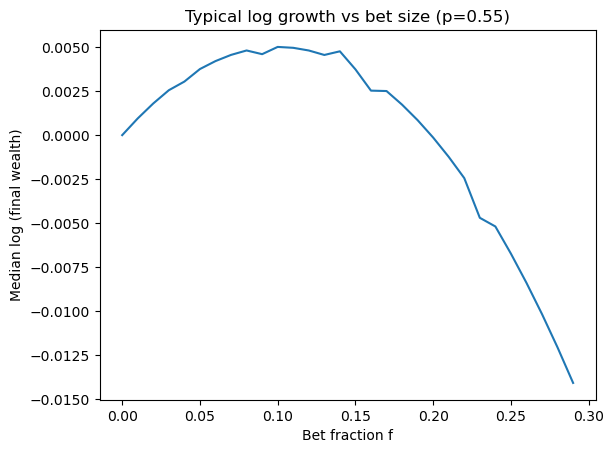

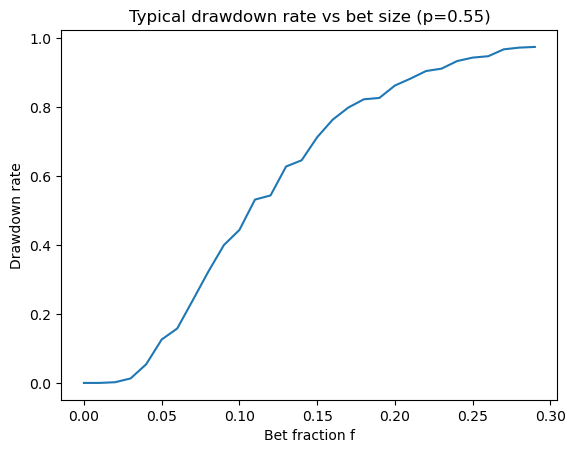

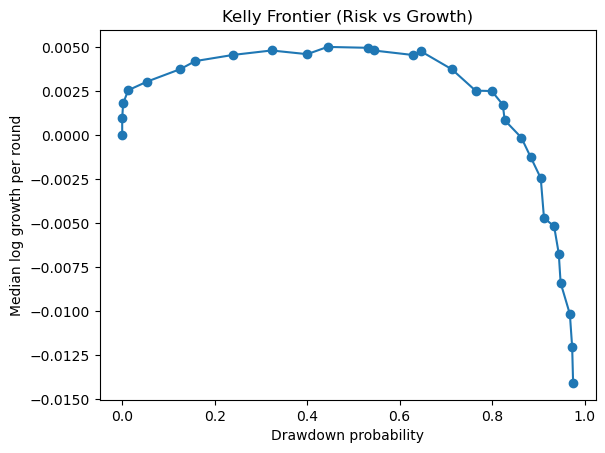

In [2]:
def simulate_path_basic(p,f,start,rounds):
    wealth = start
    wealth_vals =[start]
    for i in range(rounds):
        if random.uniform(0,1) < p:
            wealth = wealth*(1+f)
        else:
            wealth = wealth*(1-f)
        wealth_vals.append(wealth)
    return wealth_vals


strategies = {
    "Small (f=0.02)": 0.02,
    "Half Kelly (f=0.05)": 0.05,
    "Kelly (f=0.10)": 0.10,
    "Overbet (f=0.15)": 0.15
}


plt.figure()   # Figure 1: wealth




plt.figure()   # Figure 3: sweeping

median_log_final = []
f_vals = []
drawdownrate_vals = []
for g in range(30):
    f=g/100
    scores = []
    all_paths = []
    for i in range(1000):
        path = simulate_path_basic(0.55, f, 100,500)
        score = path[-1]
        scores.append(np.log(score/100)/500)
        all_paths.append(path)
    all_paths = np.array(all_paths)
    min_wealth = np.min(all_paths, axis=1)
    drawdown_rate = np.mean(min_wealth < 50)
    drawdownrate_vals.append(drawdown_rate)
    f_vals.append(f)
    median_log_final.append(np.median(scores))

plt.plot(f_vals,median_log_final)
plt.xlabel("Bet fraction f")
plt.ylabel("Median log (final wealth)")
plt.title("Typical log growth vs bet size (p=0.55)")
plt.show()

plt.figure()
plt.plot(f_vals,drawdownrate_vals)
plt.xlabel("Bet fraction f")
plt.ylabel("Drawdown rate")
plt.title("Typical drawdown rate vs bet size (p=0.55)")
plt.show()


plt.figure()
plt.plot(drawdownrate_vals, median_log_final, marker='o')

plt.xlabel("Drawdown probability")
plt.ylabel("Median log growth per round")
plt.title("Kelly Frontier (Risk vs Growth)")
plt.show()

Real markets occasionally experience large sudden losses. 
We extend the model by introducing a small probability of crash events that reduce wealth by a fixed percentage. 

We examine how this affects the optimal bet size and the risk-growth frontier. 

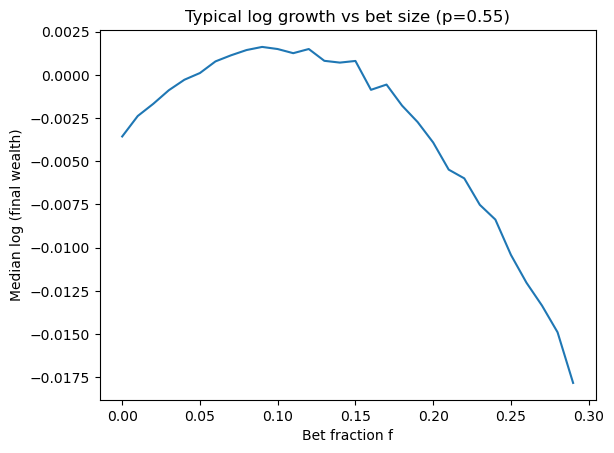

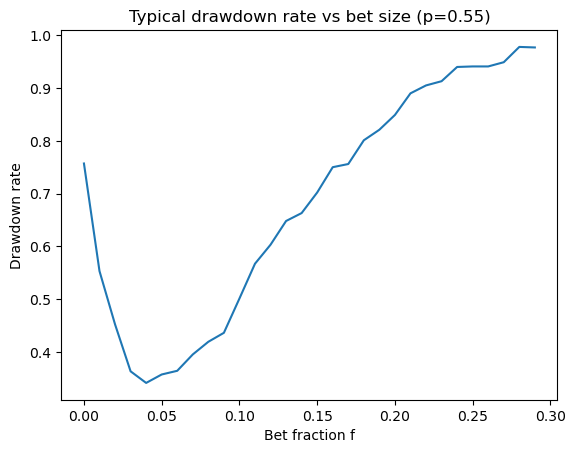

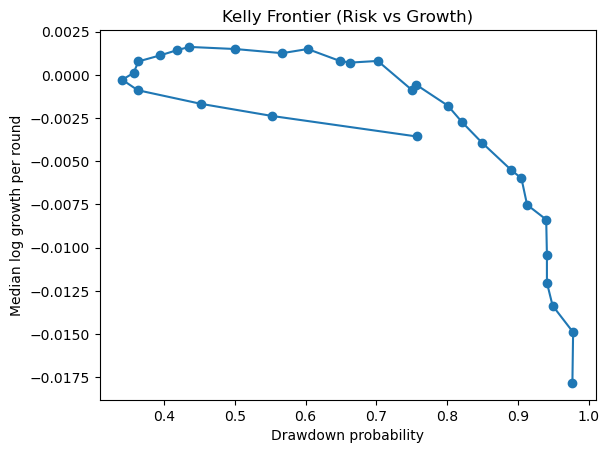

In [3]:
REGIMES = {
    "good": 0.57,
    "neutral": 0.50,
    "bad": 0.48
}


def simulate_path_crash(p,f,start,rounds):
    wealth = start
    wealth_vals =[start]
    for i in range(rounds):
        if random.uniform(0,1) < 0.01:
            wealth = wealth*0.7
        else:
            if random.uniform(0,1) < p:
                wealth = wealth*(1+f)
            else:
                wealth = wealth*(1-f)
        wealth_vals.append(wealth)
    return wealth_vals


plt.figure()   # Figure 3: sweeping

median_log_final = []
f_vals = []
drawdownrate_vals = []
for g in range(30):
    f=g/100
    scores = []
    all_paths = []
    for i in range(1000):
        path = simulate_path_crash(0.55, f, 100,500)
        score = path[-1]
        scores.append(np.log(score/100)/500)
        all_paths.append(path)
    all_paths = np.array(all_paths)
    min_wealth = np.min(all_paths, axis=1)
    drawdown_rate = np.mean(min_wealth < 30)
    drawdownrate_vals.append(drawdown_rate)
    f_vals.append(f)
    median_log_final.append(np.median(scores))

plt.plot(f_vals,median_log_final)
plt.xlabel("Bet fraction f")
plt.ylabel("Median log (final wealth)")
plt.title("Typical log growth vs bet size (p=0.55)")
plt.show()


plt.plot(f_vals,drawdownrate_vals)
plt.xlabel("Bet fraction f")
plt.ylabel("Drawdown rate")
plt.title("Typical drawdown rate vs bet size (p=0.55)")
plt.show()


plt.figure()

plt.plot(drawdownrate_vals, median_log_final, marker='o')

plt.xlabel("Drawdown probability")
plt.ylabel("Median log growth per round")
plt.title("Kelly Frontier (Risk vs Growth)")
plt.show()



Markets rarely have a constant edge. Instead we simulate three market regimes:

- Good: p = 0.57
- Neutral: p = 0.50
- Bad: p = 0.48

The true regime evolves randomly through time and is only observed with 80% accuracy. 

We compare several simple trading strategies which vary their bet size depending on the observed regime and current wealth. 

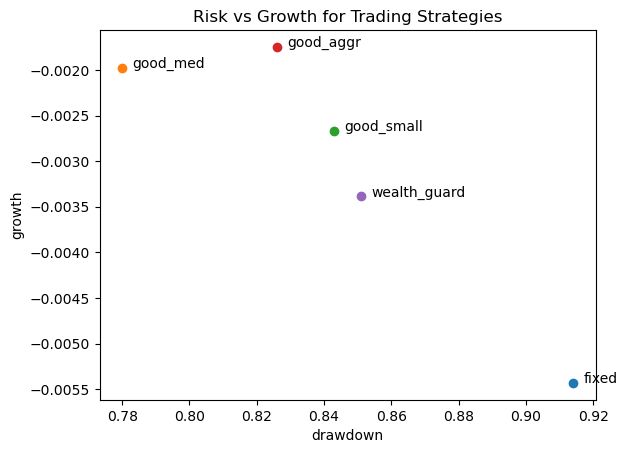

Strategy                 Growth   Drawdown
------------------------------------------
good_aggr             -0.001746      0.826
good_med              -0.001974      0.780
good_small            -0.002664      0.843
wealth_guard          -0.003385      0.851
fixed                 -0.005432      0.914


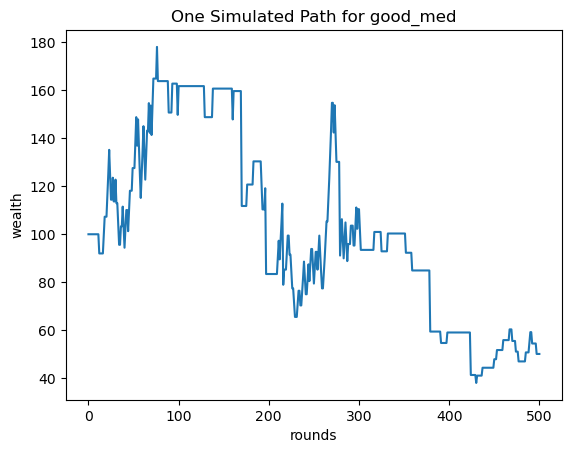

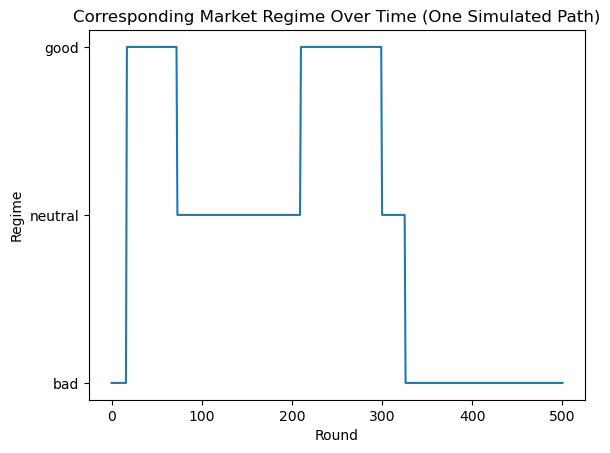

In [4]:
REGIMES = {
    "good": 0.57,
    "neutral": 0.50,
    "bad": 0.48
}

REGIME_TO_NUM = {"bad": 0, "neutral": 1, "good": 2}


def fixed_strategy(wealth,current_regime,t):
    return 0.1


def good_med(wealth,regime,t):
    if regime == "good":
        return 0.08
    elif regime == "neutral":
        return 0
    else:
        return 0

def good_small(wealth,regime,t):
    if regime == "good":
        return 0.03
    elif regime == "neutral":
        return 0
    else:
        return 0

def good_aggr(wealth,regime,t):
    if regime == "good":
        return 0.12
    elif regime == "neutral":
        return 0
    else:
        return 0

def wealth_guard(wealth,regime,t):
    if wealth < 80:
        return 0
    elif regime == "good":
        return 0.08
    else:
        return 0


strategies = [
    ("fixed", fixed_strategy),
    ("good_med", good_med),
    ("good_small", good_small),
    ("good_aggr", good_aggr),
    ("wealth_guard" , wealth_guard)
]

def simulate_path_with_regime(strategy,start,rounds,switch_prob=0.01,crash_prob=0.01,crash_mult = 0.7):
    current_regime = random.choice(list(REGIMES.keys()))
    p = REGIMES[current_regime]
    wealth = start
    wealth_vals =[start]
    regime_vals = [current_regime]
    for i in range(rounds):
        if random.uniform(0,1) < switch_prob:
            choices = [r for r in REGIMES if r != current_regime]
            current_regime = random.choice(choices)
        p = REGIMES[current_regime]
        if random.uniform(0,1) < 0.8:
            observed_regime = current_regime
        else:
            choices = [r for r in REGIMES if r != current_regime]
            observed_regime = random.choice(choices)
        f_t = strategy(wealth, observed_regime, i)
        if random.uniform(0,1) < crash_prob:
            wealth = wealth*crash_mult   
        else:
            if random.uniform(0,1) < p:
                wealth = wealth*(1+f_t)
            else:
                wealth = wealth*(1-f_t)
        wealth_vals.append(wealth)
        regime_vals.append(current_regime)
    
    return wealth_vals, regime_vals

def evaluate_strategy(strategy):
    scores = []
    all_paths = []
    for i in range(1000):
        wealth_vals , regime_vals = simulate_path_with_regime(strategy, 100,500)
        score = wealth_vals[-1]
        scores.append(np.log(score/100)/500)
        all_paths.append(wealth_vals)
    all_paths = np.array(all_paths)
    min_wealth = np.min(all_paths, axis=1)
    drawdown_rate = np.mean(min_wealth < 50)
    median_growth = np.median(scores)
    return median_growth, drawdown_rate


results = []

plt.figure()
for each in strategies:
    growth, drawdown = evaluate_strategy(each[1])
    results.append((each[0],growth,drawdown))
    plt.scatter(drawdown, growth)
    plt.text(drawdown + 0.003, growth, each[0])

plt.xlabel('drawdown')
plt.ylabel("growth")
plt.title('Risk vs Growth for Trading Strategies')
plt.show()

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
print(f"{'Strategy':<20} {'Growth':>10} {'Drawdown':>10}")
print("-" * 42)
for name, growth, drawdown in results_sorted:
    print(f"{name:<20} {growth:>10.6f} {drawdown:>10.3f}")


wealth_vals, regime_vals = simulate_path_with_regime(good_med,100,500)
plt.figure()
plt.plot(wealth_vals)
plt.xlabel('rounds')
plt.ylabel('wealth')
plt.title("One Simulated Path for good_med")
plt.show()

plt.figure()
plt.plot([REGIME_TO_NUM[r] for r in regime_vals])
plt.yticks([0,1,2], ["bad", "neutral", "good"])
plt.xlabel("Round")
plt.ylabel("Regime")
plt.title("Corresponding Market Regime Over Time (One Simulated Path)")
plt.show()



Across the simulations, strategies that bet moderately during favourable regimes while avoiding neutral and bad regimes perform best. 

Aggressive strategies can achieve higher growth but experience larger drawdowns, while conservative strategies reduce risk at the cost of growth. 

This highlights the fundamental trade-off between risk and growth in Kelly-style position sizing under uncertain market conditions. 